<a href="https://colab.research.google.com/github/lipikaise2026-stack/Machine-Learning-Projects/blob/main/Netflix_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# STEP 1 - Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

data = {
    "type": ["Movie", "TV Show", "Movie", "Movie", "TV Show"],
    "release_year": [2020, 2019, 2021, 2018, 2022],
    "rating": ["PG", "TV-MA", "PG-13", "R", "TV-14"],
    "duration": [120, 3, 140, 110, 2],
    "country": ["India", "USA", "UK", "India", "Canada"]
}

df = pd.DataFrame(data)

df.to_csv("netflix.csv", index=False)

print("Dataset created successfully!")
df

Dataset created successfully!


,type,release_year,rating,duration,country
0,Movie,2020,PG,120,India
1,TV Show,2019,TV-MA,3,USA
2,Movie,2021,PG-13,140,UK
3,Movie,2018,R,110,India
4,TV Show,2022,TV-14,2,Canada


In [ ]:
# ==========================================
# STEP 2 - Data Collection
# Load the Netflix dataset
# ==========================================

df = pd.read_csv("netflix.csv")      # Change filename if needed

# Display first 5 rows
df.head()

,type,release_year,rating,duration,country
0,Movie,2020,PG,120,India
1,TV Show,2019,TV-MA,3,USA
2,Movie,2021,PG-13,140,UK
3,Movie,2018,R,110,India
4,TV Show,2022,TV-14,2,Canada


In [ ]:
# ==========================================
# Check Dataset Information
# ==========================================

print(df.shape)

df.info()

df.describe(include='all')

# Display column names
print(df.columns)

(5, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          5 non-null      object
 1   release_year  5 non-null      int64 
 2   rating        5 non-null      object
 3   duration      5 non-null      int64 
 4   country       5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
Index(['type', 'release_year', 'rating', 'duration', 'country'], dtype='object')


In [ ]:
# ==========================================
# STEP 4 - Data Cleaning
# ==========================================

# Check missing values
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Fill missing values

df.fillna("Unknown", inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

type            0
release_year    0
rating          0
duration        0
country         0
dtype: int64
Missing values after cleaning:
type            0
release_year    0
rating          0
duration        0
country         0
dtype: int64


In [ ]:
# ==========================================
# STEP 5 - Data Preprocessing
# ==========================================

# Convert categorical columns into numbers

label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,type,release_year,rating,duration,country
0,0,2020,0,120,1
1,1,2019,4,3,3
2,0,2021,1,140,2
3,0,2018,2,110,1
4,1,2022,3,2,0


In [ ]:
# ==========================================
# STEP 6 - Feature Selection
# ==========================================

# Target Variable
y = df["type"]

# Features
X = df.drop("type", axis=1)

print(X.head())

   release_year  rating  duration  country
0          2020       0       120        1
1          2019       4         3        3
2          2021       1       140        2
3          2018       2       110        1
4          2022       3         2        0


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4, 4)
(1, 4)


In [ ]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ==========================================
# STEP 9 - Model Selection
# ==========================================

model = RandomForestClassifier(random_state=42)

In [ ]:
# ==========================================
# STEP 10 - Train the Model
# ==========================================

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
# Make predictions

y_pred = model.predict(X_test)

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



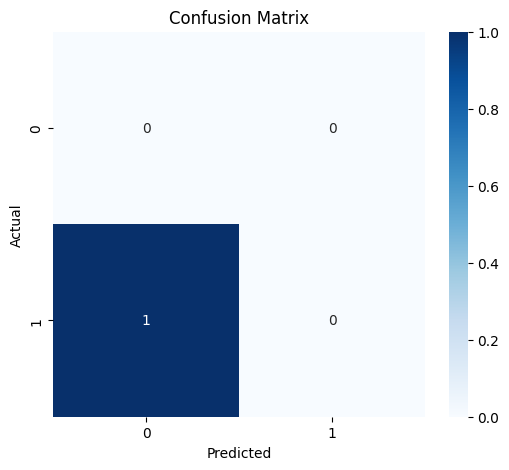

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================
# STEP 13 - Hyperparameter Tuning
# ==========================================

parameters = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best Score:
0.8333333333333334


In [ ]:
# ==========================================
# STEP 14 - Deployment
# Save trained model
# ==========================================

import joblib

joblib.dump(model, "netflix_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
# ==========================================
# STEP 15 - Monitoring
# ==========================================

# Predict on new incoming data

sample = X_test[:5]

prediction = model.predict(sample)

print("Predictions:")

print(prediction)

# In real-world applications, the model should be retrained
# periodically with newly collected Netflix data.

Predictions:
[0]
